In [85]:

from sklearn.metrics import r2_score , mean_squared_error
from sklearn.model_selection import train_test_split , cross_val_score , cross_val_predict , GridSearchCV
from sklearn.linear_model import LinearRegression , Ridge
from sklearn.preprocessing import PolynomialFeatures , StandardScaler 

In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
import requests  
import matplotlib.pyplot as plt

In [87]:
df = pd.read_csv("kc_house_data_NaN.csv")
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [88]:
def limpia_datos(name_column):
    avg = df[name_column].astype('float').mean(axis = 0)
    df[name_column].replace(np.nan , avg , inplace=True)
    print(f'El valor promedio es {avg} de la columna {name_column} ')

In [89]:
limpia_datos('sqft_living')
limpia_datos('grade')
limpia_datos('bathrooms')

El valor promedio es 2079.8997362698374 de la columna sqft_living 
El valor promedio es 7.656873178179799 de la columna grade 
El valor promedio es 2.1157362403369904 de la columna bathrooms 


C:\Users\Estudiante\AppData\Local\Temp\ipykernel_6104\241534462.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[name_column].replace(np.nan , avg , inplace=True)
C:\Users\Estudiante\AppData\Local\Temp\ipykernel_6104\241534462.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [90]:
df.columns

Index(['Unnamed: 0', 'id', 'date', 'price', 'bedrooms', 'bathrooms',
       'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
       'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [91]:
y_data  = df['price']
x_data = df.drop(columns='price' , inplace=True)


## Regrecion Lineal Simple

In [92]:
### modelo regrecion simple
lr = LinearRegression()
y_data1  = y_data  
x_data1 = df[["sqft_living"]]

lr.fit(x_data1 , y_data1)
lr.predict(x_data1)

print(f"La intercession es de {lr.intercept_}")
print(f"Los coeficientes son {lr.coef_}")

##datos predichos
yhat1 = lr.predict(x_data1)

La intercession es de -43580.74309447466
Los coeficientes son [280.6235679]


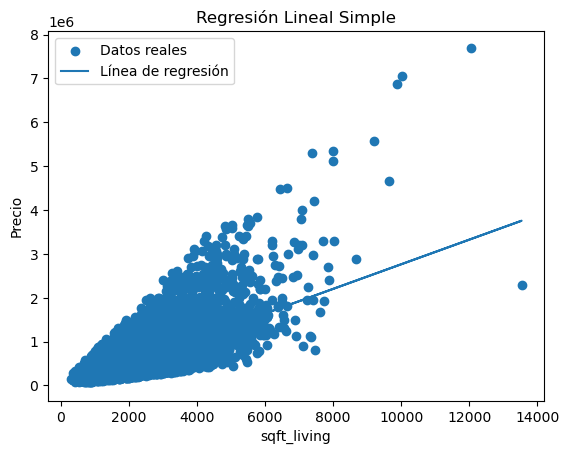

In [93]:
import matplotlib.pyplot as plt

# Datos reales
plt.scatter(x_data1, y_data1, label="Datos reales" )

# Línea de regresión
plt.plot(x_data1, yhat1, label="Línea de regresión")

# Etiquetas
plt.xlabel("sqft_living")
plt.ylabel("Precio")
plt.title("Regresión Lineal Simple")

# Leyenda
plt.legend()


plt.show()

## Regrecion Lineal Multiple


In [97]:
### modelo regrecion simple
lr = LinearRegression()
y_data2  = y_data  
x_data2 = df[['sqft_living', 'grade', 'bathrooms']]

lr.fit(x_data2 , y_data2)
lr.predict(x_data2)

print(f"La intercession es de {lr.intercept_}")
print(f"Los coeficientes son {lr.coef_}")

##datos predichos
yhat2 = lr.predict(x_data2)

La intercession es de -597296.5061113389
Los coeficientes son [   203.20915677 103787.83394161 -37793.13512488]


In [101]:
print(f"El coeficiente de error es de : {r2_score(y_data2  , yhat2 )}")
print(f"El coeficiente de error es de : {mean_squared_error(y_data2  , yhat2 )}")

El coeficiente de error es de : 0.5370747312142029
El coeficiente de error es de : 62391281865.685974


## Regrecion Lineal Polinmica


In [103]:


# Variables
x_data3 = df[['sqft_living', 'grade', 'bathrooms']]
y_data3 = y_data  

# Transformación polinómica
pr = PolynomialFeatures(degree=3)
X_poly = pr.fit_transform(x_data3)

# Modelo
lr = LinearRegression()
lr.fit(X_poly, y_data3)

# Predicciones
yhat3 = lr.predict(X_poly)


print(f"El coeficiente de error es de : {r2_score(y_data3  , yhat3 )}")
print(f"El MSE de error es de : {mean_squared_error(y_data3  , yhat3 )}")

El coeficiente de error es de : 0.6065444268728533
El MSE de error es de : 53028424283.22847
